# Synthetic dimension-scaling metrics

This notebook summarizes downloaded synthetic experiments across seeds. It reports the median and interquartile interval (0.25–0.75 quantiles) for:

- **HDR volume ratio:** analytic HDR volume divided by the learned transport-ball volume. Values closer to 1 are better.
- **Marginal coverage:** empirical conformal coverage. The dashed reference is the configured target coverage.

Only saved `config.json` and `metrics.json` files are read; models are not loaded or recomputed.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def find_repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd())
RESULTS_CANDIDATES = [
    REPOSITORY_ROOT / "downloads/synthetic_dimension_scaling",
    REPOSITORY_ROOT / "benchmark/downloads/results/synthetic_dimension_scaling",
]
RESULTS_ROOT = next((root for root in RESULTS_CANDIDATES if root.is_dir()), None)
if RESULTS_ROOT is None:
    searched = "\n".join(str(root) for root in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"Synthetic results were not found. Searched:\n{searched}")

# Primary dimensions of interest. Add 16 or 32 when those downloads complete.
DIMENSIONS = [2, 4, 8]
SELECTED_DATASETS = None  # None selects every available dataset.
SELECTED_METHODS = ["neural_ot_l2", "neural_ot_rearranged_l2"]

METHOD_LABELS = {
    "neural_ot_l2": "Neural OT",
    "neural_ot_rearranged_l2": "Neural OT + rearrangement",
}
DATASET_LABELS = {
    "banana": "Banana",
    "sinusoidal_transport": "Sinusoidal transport",
    "star_shaped_gaussian": "Star-shaped Gaussian",
}

sns.set_theme(style="whitegrid", context="notebook")
print(f"Repository: {REPOSITORY_ROOT}")
print(f"Results:    {RESULTS_ROOT}")

Repository: <repository-root>
Results:    benchmark/downloads/results/synthetic_dimension_scaling


In [2]:
records = []
skipped = []

for config_path in sorted(RESULTS_ROOT.glob("*/dim_*/*/seed_*/config.json")):
    relative_parts = config_path.relative_to(RESULTS_ROOT).parts
    dataset, dimension_folder, method, seed_folder = relative_parts[:4]
    dimension = int(dimension_folder.removeprefix("dim_"))

    if dimension not in DIMENSIONS or method not in SELECTED_METHODS:
        continue
    if SELECTED_DATASETS is not None and dataset not in SELECTED_DATASETS:
        continue

    metrics_path = config_path.parent / "metrics.json"
    if not metrics_path.is_file():
        skipped.append({"run": str(config_path.parent), "reason": "missing metrics.json"})
        continue

    with config_path.open(encoding="utf-8") as file:
        config = json.load(file)
    with metrics_path.open(encoding="utf-8") as file:
        metrics = json.load(file)

    try:
        volume_ratio = float(metrics["hdr_volume_ratio"]["mean"])
        coverage = float(metrics["marginal_coverage"]["mean"])
    except (KeyError, TypeError, ValueError) as error:
        skipped.append({"run": str(config_path.parent), "reason": repr(error)})
        continue

    records.append({
        "dataset": dataset,
        "dataset_label": DATASET_LABELS.get(dataset, dataset),
        "dimension": dimension,
        "method": method,
        "method_label": METHOD_LABELS.get(method, method),
        "seed": int(config.get("seed", seed_folder.removeprefix("seed_"))),
        "volume_ratio": volume_ratio,
        "coverage": coverage,
        "target_coverage": float(metrics.get("target_coverage", 0.9)),
        "run_directory": str(config_path.parent.relative_to(REPOSITORY_ROOT)),
    })

results = pd.DataFrame(records)
if results.empty:
    raise RuntimeError("No matching completed runs were found.")
results = results.sort_values(
    ["dataset", "method", "dimension", "seed"]
).reset_index(drop=True)

print(f"Loaded {len(results)} completed runs.")
print(
    results.groupby(["dataset_label", "method_label", "dimension"])
    .size()
    .rename("runs")
    .to_string()
)
if skipped:
    print(f"Skipped {len(skipped)} selected runs; inspect `pd.DataFrame(skipped)` for details.")

Loaded 175 completed runs.
dataset_label         method_label               dimension
Banana                Neural OT                  2            10
                                                 4            10
                                                 8            10
                      Neural OT + rearrangement  2            10
                                                 4            10
                                                 8             5
Sinusoidal transport  Neural OT                  2            10
                                                 4            10
                                                 8            10
                      Neural OT + rearrangement  2            10
                                                 4            10
                                                 8            10
Star-shaped Gaussian  Neural OT                  2            10
                                                 4            10
    

In [3]:
summary = (
    results.groupby(
        ["dataset", "dataset_label", "method", "method_label", "dimension"],
        as_index=False,
    )
    .agg(
        runs=("seed", "size"),
        volume_q25=("volume_ratio", lambda values: values.quantile(0.25)),
        volume_median=("volume_ratio", "median"),
        volume_q75=("volume_ratio", lambda values: values.quantile(0.75)),
        coverage_q25=("coverage", lambda values: values.quantile(0.25)),
        coverage_median=("coverage", "median"),
        coverage_q75=("coverage", lambda values: values.quantile(0.75)),
        target_coverage=("target_coverage", "median"),
    )
    .sort_values(["dataset", "method", "dimension"])
    .reset_index(drop=True)
)

display_columns = [
    "dataset_label",
    "method_label",
    "dimension",
    "runs",
    "volume_q25",
    "volume_median",
    "volume_q75",
    "coverage_q25",
    "coverage_median",
    "coverage_q75",
]
display(
    summary[display_columns]
    .rename(columns={
        "dataset_label": "dataset",
        "method_label": "method",
        "dimension": "dim",
        "volume_q25": "volume q25",
        "volume_median": "volume median",
        "volume_q75": "volume q75",
        "coverage_q25": "coverage q25",
        "coverage_median": "coverage median",
        "coverage_q75": "coverage q75",
    })
    .style.format(precision=4)
)

,dataset,method,dim,runs,volume q25,volume median,volume q75,coverage q25,coverage median,coverage q75
0,Banana,Neural OT,2,10,0.3798,0.4296,0.5027,0.8908,0.9000,0.9055
1,Banana,Neural OT,4,10,0.3990,0.4118,0.4501,0.8922,0.9005,0.9115
2,Banana,Neural OT,8,10,0.3689,0.4287,0.4707,0.8843,0.9055,0.9170
3,Banana,Neural OT + rearrangement,2,10,0.9316,0.9605,0.9709,0.8930,0.8980,0.9105
4,Banana,Neural OT + rearrangement,4,10,0.8928,0.9116,0.9277,0.8860,0.8975,0.9040
5,Banana,Neural OT + rearrangement,8,5,0.8587,0.8863,0.8991,0.9000,0.9020,0.9070
6,Sinusoidal transport,Neural OT,2,10,0.8767,0.8901,0.9008,0.8870,0.8985,0.9055
7,Sinusoidal transport,Neural OT,4,10,0.8708,0.8780,0.9000,0.8872,0.8970,0.9070
8,Sinusoidal transport,Neural OT,8,10,0.8720,0.8881,0.9088,0.8912,0.8950,0.9003
9,Sinusoidal transport,Neural OT + rearrangement,2,10,0.9730,0.9761,0.9831,0.8930,0.8960,0.9025


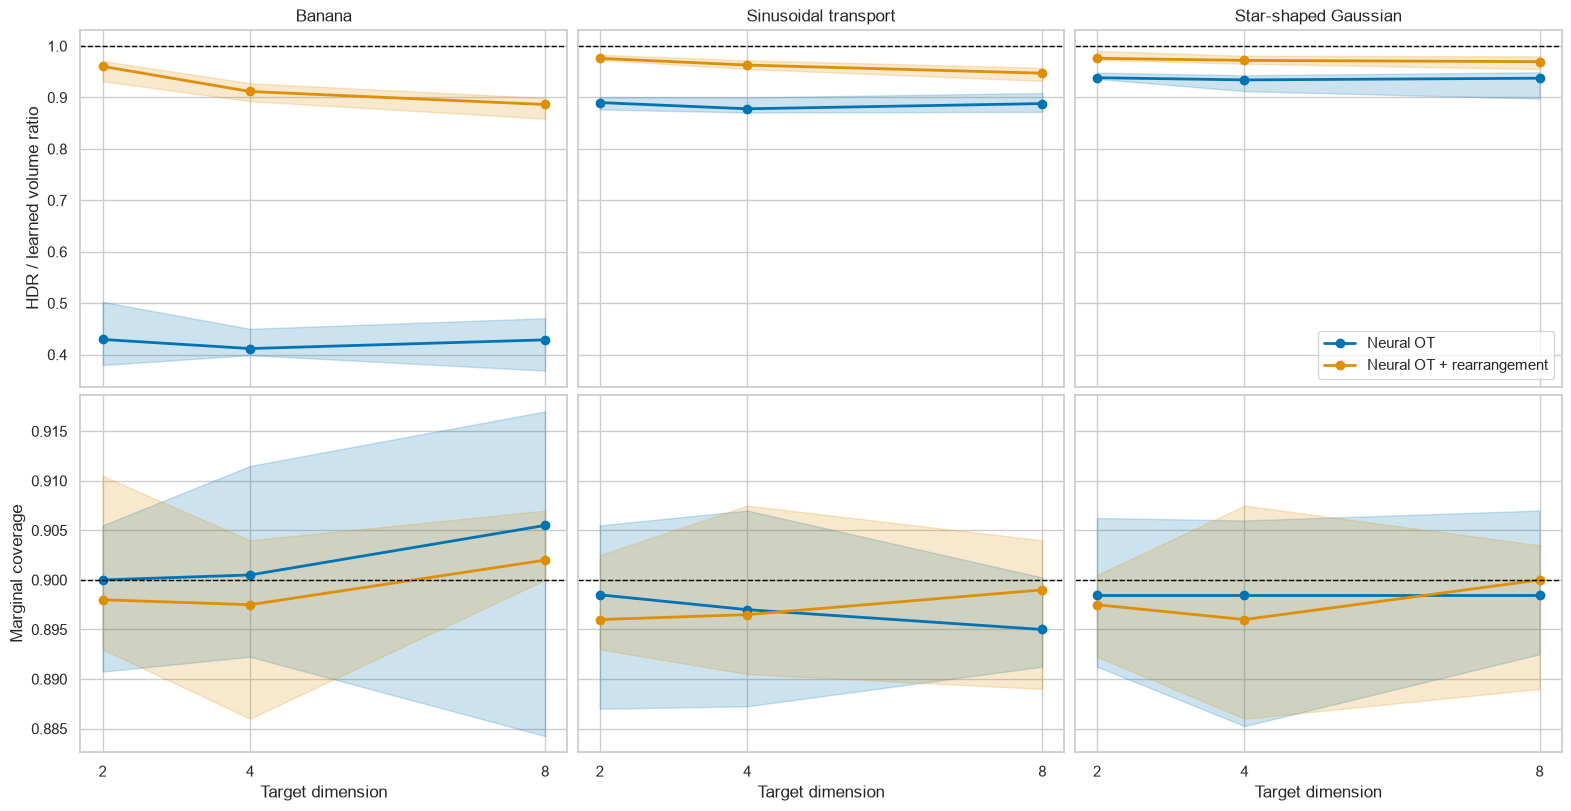

In [4]:
datasets = list(dict.fromkeys(summary["dataset"]))
palette = dict(
    zip(SELECTED_METHODS, sns.color_palette("colorblind", len(SELECTED_METHODS)))
)
figure, axes = plt.subplots(
    2,
    len(datasets),
    figsize=(5.2 * len(datasets), 8),
    sharex=True,
    sharey="row",
    squeeze=False,
    constrained_layout=True,
)

for column, dataset in enumerate(datasets):
    dataset_summary = summary[summary["dataset"] == dataset]
    for method in SELECTED_METHODS:
        values = dataset_summary[dataset_summary["method"] == method].sort_values("dimension")
        if values.empty:
            continue

        x = values["dimension"].to_numpy(dtype=float)
        color = palette[method]
        label = METHOD_LABELS.get(method, method)

        axes[0, column].fill_between(
            x,
            values["volume_q25"].to_numpy(dtype=float),
            values["volume_q75"].to_numpy(dtype=float),
            color=color,
            alpha=0.20,
        )
        axes[0, column].plot(
            x,
            values["volume_median"].to_numpy(dtype=float),
            color=color,
            marker="o",
            linewidth=2,
            label=label,
        )
        axes[1, column].fill_between(
            x,
            values["coverage_q25"].to_numpy(dtype=float),
            values["coverage_q75"].to_numpy(dtype=float),
            color=color,
            alpha=0.20,
        )
        axes[1, column].plot(
            x,
            values["coverage_median"].to_numpy(dtype=float),
            color=color,
            marker="o",
            linewidth=2,
            label=label,
        )

    target_coverage = float(dataset_summary["target_coverage"].median())
    axes[0, column].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1, column].axhline(
        target_coverage, color="black", linestyle="--", linewidth=1
    )
    axes[0, column].set_title(DATASET_LABELS.get(dataset, dataset))
    axes[1, column].set_xlabel("Target dimension")
    axes[1, column].set_xticks(DIMENSIONS)

axes[0, 0].set_ylabel("HDR / learned volume ratio")
axes[1, 0].set_ylabel("Marginal coverage")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, -1].legend(handles, labels, loc="lower right")
plt.show()